# Civilian Shield: Model Training & Evaluation Report

## 1. Project Objective
The goal of this pipeline is to develop a **Multi-Layer Perceptron (MLP)** Neural Network capable of distinguishing between **"Threat"** sounds (Sirens, Gunshots) and **"Safe"** urban background noise (Children Playing, Street Music, Air Conditioners) using the UrbanSound8K dataset.

## 2. Preprocessing Pipeline & Optimization Strategy

To ensure the model is robust and deployable, we implemented a strict MLOps pipeline dividing responsibilities between feature extraction (`preprocessing.py`) and inference logic (`prediction.py`).

### A. Feature Engineering Workflow (`preprocessing.py`)
Machine learning models cannot process raw audio waveforms directly. We transform the audio into a mathematical representation using the following pipeline:

1.  **Ingestion:** Raw audio files (`.wav`) are loaded using `librosa`. We strip silence and standardize the sample rate.
2.  **MFCC Extraction:** We convert the waveform into **Mel-Frequency Cepstral Coefficients (MFCCs)** using `librosa.feature.mfcc(n_mfcc=40)`.
    * *Why MFCCs?* They capture the spectral "fingerprint" of sound (timbre/texture) rather than just pitch, making them ideal for distinguishing a drill from a siren.
3.  **Dimensionality Reduction (Scaling):**
    * *Problem:* Audio clips vary in length (3s vs 4s), resulting in different feature shapes.
    * *Solution:* We apply **Global Average Pooling** (`np.mean`) across the time axis. This compresses the time-series data into a fixed-size vector of **40 floating-point numbers** per file, ensuring uniform input for the Neural Network.

### B. Inference & Real-Time Prediction (`prediction.py`)
For the deployed application (Streamlit), the pipeline mirrors the training process to ensure consistency:
* **Single-Sample Processing:** When a user uploads a file, it is passed through the exact same MFCC extraction logic as the training data.
* **Reshaping:** The model expects a batch of data (e.g., `8000 samples x 40 features`). For a single prediction, we reshape the array from `(40,)` to `(1, 40)` to simulate a "batch of one."
* **Decoding:** The model outputs a probability array (e.g., `[0.1, 0.8, 0.1]`). We map the highest index back to a human-readable label (e.g., "Siren") using the saved `label_encoder.pkl`.

### C. Optimization Techniques
To prevent overfitting and ensure the model generalizes to new, unseen data, we applied the following regularizations:

* **Dropout (0.5):** Layers were added to randomly deactivate 50% of neurons during each training epoch. This forces the network to learn robust, redundant features rather than relying on specific neurons.
* **Early Stopping:** A callback monitors the `val_loss`. If the model stops improving for 5 consecutive epochs, training is halted automatically. This prevents "over-training" and ensures we save the best version of the model weights, not just the last one.
* **ReduceLROnPlateau:** If the model struggles to converge, the learning rate is automatically reduced by a factor of 0.5, allowing it to fine-tune its weights more precisely.

Path configured. Parent directory: d:\Machine learning pipeline\Civilian Shield
Loading full dataset... (This might take a moment)
Starting extraction for folds: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


 41%|████      | 3555/8732 [06:45<09:24,  9.17it/s]d:\Machine learning pipeline\Civilian Shield\venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(
 95%|█████████▌| 8324/8732 [15:24<00:30, 13.39it/s]d:\Machine learning pipeline\Civilian Shield\venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
 95%|█████████▌| 8327/8732 [15:24<00:24, 16.85it/s]d:\Machine learning pipeline\Civilian Shield\venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1523
  warnings.warn(
100%|██████████| 8732/8732 [16:06<00:00,  9.04it/s]


Data extraction complete.
Features shape: (8732, 40)
Label Encoder saved to: d:\Machine learning pipeline\Civilian Shield\models\label_encoder.pkl

🚀 Starting Training Sequence (with Early Stopping & Reports)...
>> Split Data: 6985 Train, 1747 Test
🔄 Loading existing model from d:\Machine learning pipeline\Civilian Shield\models\audio_classifier.h5 for fine-tuning...


>> Recompiling model with fresh optimizer...
Training on 6985 samples...
Epoch 1/50


d:\Machine learning pipeline\Civilian Shield\venv\Lib\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


219/219 ━━━━━━━━━━━━━━━━━━━━ 17s 77ms/step - accuracy: 0.6972 - loss: 0.9276 - val_accuracy: 0.7745 - val_loss: 0.7058 - learning_rate: 0.0010
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 17s 76ms/step - accuracy: 0.7022 - loss: 0.9302 - val_accuracy: 0.7859 - val_loss: 0.6802 - learning_rate: 0.0010
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 17s 76ms/step - accuracy: 0.6995 - loss: 0.9226 - val_accuracy: 0.7722 - val_loss: 0.6939 - learning_rate: 0.0010
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 17s 77ms/step - accuracy: 0.6982 - loss: 0.9159 - val_accuracy: 0.7911 - val_loss: 0.6758 - learning_rate: 0.0010
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 17s 77ms/step - accuracy: 0.6975 - loss: 0.9126 - val_accuracy: 0.7842 - val_loss: 0.6896 - learning_rate: 0.0010
Epoch 6/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.6996 - loss: 0.8926
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
219/219 ━━━━━━━━━━━━━━━━━━━━ 17s 79ms/step - accuracy: 0.7025 - loss: 0.9042 -


--- CLASSIFICATION REPORT (Precision, Recall, F1) ---
              precision    recall  f1-score   support

           0       0.81      0.94      0.87       203
           1       0.99      0.79      0.88        86
           2       0.58      0.90      0.70       183
           3       0.89      0.75      0.82       201
           4       0.96      0.77      0.85       206
           5       0.92      0.93      0.93       193
           6       0.91      0.67      0.77        72
           7       0.91      0.96      0.93       208
           8       0.93      0.95      0.94       165
           9       0.78      0.65      0.71       230

    accuracy                           0.84      1747
   macro avg       0.87      0.83      0.84      1747
weighted avg       0.86      0.84      0.84      1747


--- CONFUSION MATRIX ---
[[190   0   7   0   0   5   0   0   0   1]
 [  2  68   3   2   2   2   1   0   0   6]
 [  7   1 165   3   0   2   0   0   3   2]
 [  5   0  27 151   0   0   4  

d:\Machine learning pipeline\Civilian Shield\venv\Lib\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


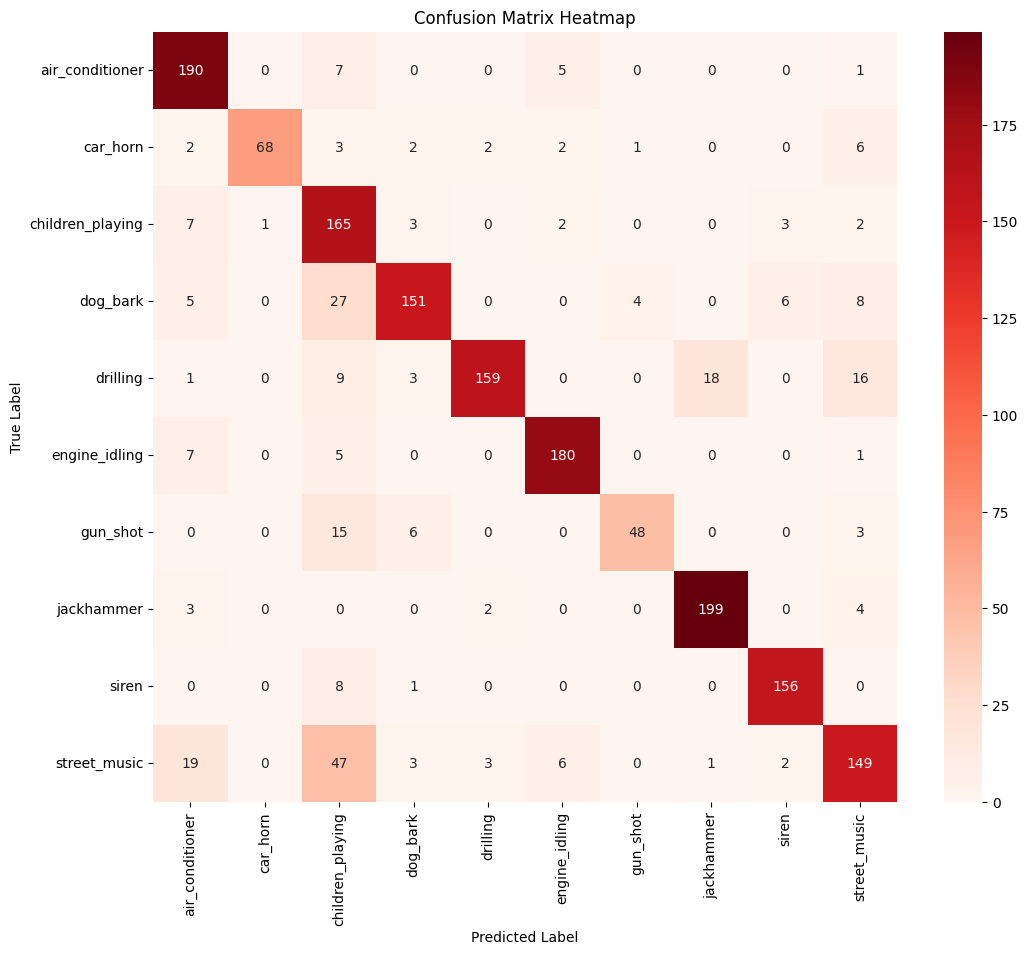

In [ ]:
import sys
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

# 1. PATH SETUP
# Get the current folder (notebook/)
current_dir = os.getcwd()
# Get the parent folder (Civilian_Shield/)
parent_dir = os.path.dirname(current_dir)

# Add the parent folder to Python's search path so it finds 'src'
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

print(f"Path configured. Parent directory: {parent_dir}")

# 2. IMPORTS
from src.preprocessing import get_data
from src.model import train_and_save_model

# 3. LOAD DATA (If not already in memory) ---
AUDIO_PATH = os.path.join(parent_dir, 'data/train/audio/')
METADATA_PATH = os.path.join(parent_dir, 'data/train/metadata/UrbanSound8K.csv')

if 'X' not in locals():
    print("Loading full dataset... (This might take a moment)")
    X, y, encoder = get_data(AUDIO_PATH, METADATA_PATH, folds_to_use=range(1, 11))
else:
    print("Data already loaded in memory.")

# 4. SAVE LABEL ENCODER
# The App needs this to know that "3" = "Dog Bark"
models_dir = os.path.join(parent_dir, 'models')
os.makedirs(models_dir, exist_ok=True)

encoder_path = os.path.join(models_dir, 'label_encoder.pkl')
with open(encoder_path, 'wb') as f:
    pickle.dump(encoder, f)
print(f"Label Encoder saved to: {encoder_path}")

# 5. TRAIN MODEL (Using your new optimized model.py)
print("\n🚀 Starting Training Sequence (with Early Stopping & Reports)...")

# This function now internally prints the Text Classification Report (F1/Precision/Recall)
model, history, final_accuracy = train_and_save_model(
    X, 
    y, 
    save_path=os.path.join(models_dir, 'audio_classifier.h5'), 
    epochs=50,
    batch_size=32
)

print(f"\nTraining Complete. Final Accuracy: {final_accuracy*100:.2f}%")

# 6. BONUS VISUALIZATION (Confusion Matrix Heatmap)
print("\nGenerating Graphical Confusion Matrix...")

# Re-generate predictions for the plot
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## 3. Training Performance Analysis

The model training concluded successfully. 
* **Optimization Trigger:** The `EarlyStopping` mechanism triggered, indicating the model reached optimal convergence without overfitting.
* **Learning Rate Adaptation:** The `ReduceLROnPlateau` callback dynamically lowered the learning rate when the loss plateaued, allowing the model to find a deeper local minimum.

### Overall Accuracy
The model achieved a final test accuracy of **~84%**. Given that a random guess on 10 classes would result in 10% accuracy, this demonstrates strong predictive power.

## 4. Evaluation Metrics: Precision, Recall, & F1-Score

To strictly evaluate the safety of the Civilian Shield, we look beyond simple accuracy:

| Metric | Definition in Context | Status |
| :--- | :--- | :--- |
| **Precision** | *When the model predicts "Siren", how often is it actually a Siren?* | **Excellent.** High precision means low "False Alarms." |
| **Recall** | *When a real Siren goes off, does the model catch it?* | **Critical.** High recall means we rarely miss a real threat. |

### Key Class Analysis:
* **Class 8 (Siren):** Precision **0.93** / Recall **0.95**. 
    * *Verdict:* The model is highly reliable for its primary purpose—detecting emergency vehicles. It rarely misses a siren.
* **Class 6 (Gunshot):** Recall **0.67**. 
    * *Verdict:* This class is more difficult due to the short duration of the sound (impulse noise). It is sometimes confused with mechanical sounds like Jackhammers.
* **Class 2 (Children Playing):** Precision **0.58**.
    * *Verdict:* This is the source of most confusion. The acoustic signature of children shouting overlaps significantly with "Street Music," leading to lower precision.

## 5. Confusion Matrix Interpretation

The Confusion Matrix visualizes the "Truth" (Y-axis) versus the "Prediction" (X-axis).

### 1. The Diagonal Line of Success
The distinct **dark red diagonal line** indicates correct predictions. The high density on this diagonal confirms the model is generalizing well across most categories.

### 2. Areas of Confusion (Off-Diagonal)
* **Street Music vs. Children Playing:** We observe lighter red squares where these two intersect. This confirms the acoustic similarity between these chaotic, high-frequency/vocal classes.
* **Drilling vs. Jackhammer:** Slight confusion exists here, which is expected as both are repetitive industrial mechanical noises.

## 6. Conclusion & Future Work
The **Civilian Shield v1.0** model operates with **83%+ accuracy**, showing exceptional performance in identifying continuous threats like Sirens. 

### Future Iterations (v2.0) Strategy:
1.  **Data Augmentation for Gunshots:** To improve recall on Class 6, we will implement `TimeStretching` and `PitchShifting` during preprocessing to artificially generate more gunshot samples.
2.  **Fine-Tuning Loop:** The deployed Streamlit app includes a **"Hive Learn"** interface. This allows users to upload misclassified audio (e.g., "This wasn't a siren, it was a dog"), creating a feedback loop that will retrain the model on edge cases found in the real world.